In [1]:
## Name: Tushar Agrawal

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the CSV file
df = pd.read_csv("Housing.csv")

# first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# no. rows and columns
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 545
Columns: 13


In [5]:
#column names and data types
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
#Task- 2

# Handle missing values
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for c in numeric_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in categorical_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [8]:
# Removing duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicate rows removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicate rows removed: 0
Rows remaining: 545


In [9]:
# Converting categorical columns to numeric using one-hot encoding
binary_cols = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]

multi_cat_cols = ["furnishingstatus"]

df_encoded = pd.get_dummies(df, columns=binary_cols + multi_cat_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [10]:
print("Final shape:", df_encoded.shape)
df_encoded.columns.tolist()

Final shape: (545, 14)


['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [11]:
# Task- 3
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 436
Testing rows: 109


In [12]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print(f"  MAE  : {lr_mae:,.0f}")
print(f"  RMSE : {lr_rmse:,.0f}")
print(f"  R2   : {lr_r2:.3f}")

Linear Regression
  MAE  : 970,043
  RMSE : 1,324,507
  R2   : 0.653


In [13]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor")
print(f"  MAE  : {rf_mae:,.0f}")
print(f"  RMSE : {rf_rmse:,.0f}")
print(f"  R2   : {rf_r2:.3f}")

Random Forest Regressor
  MAE  : 1,013,969
  RMSE : 1,398,116
  R2   : 0.613


In [14]:
# Compare both models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


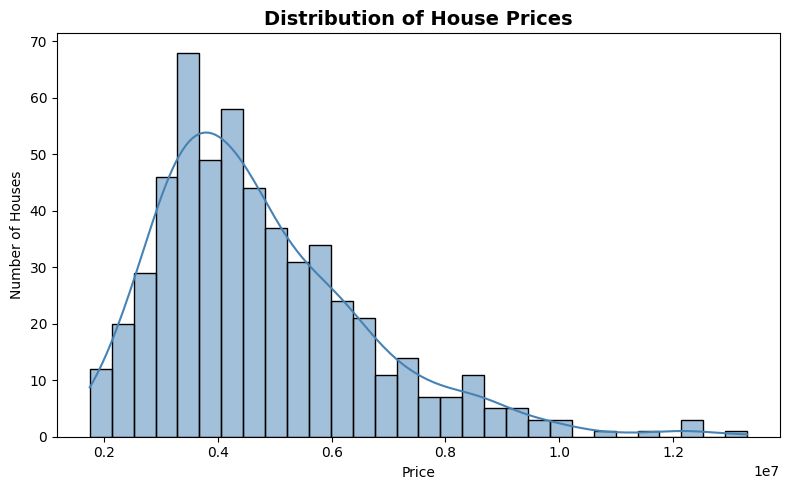

In [15]:
# Chart 1 : Price distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices", fontsize=14, weight="bold")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

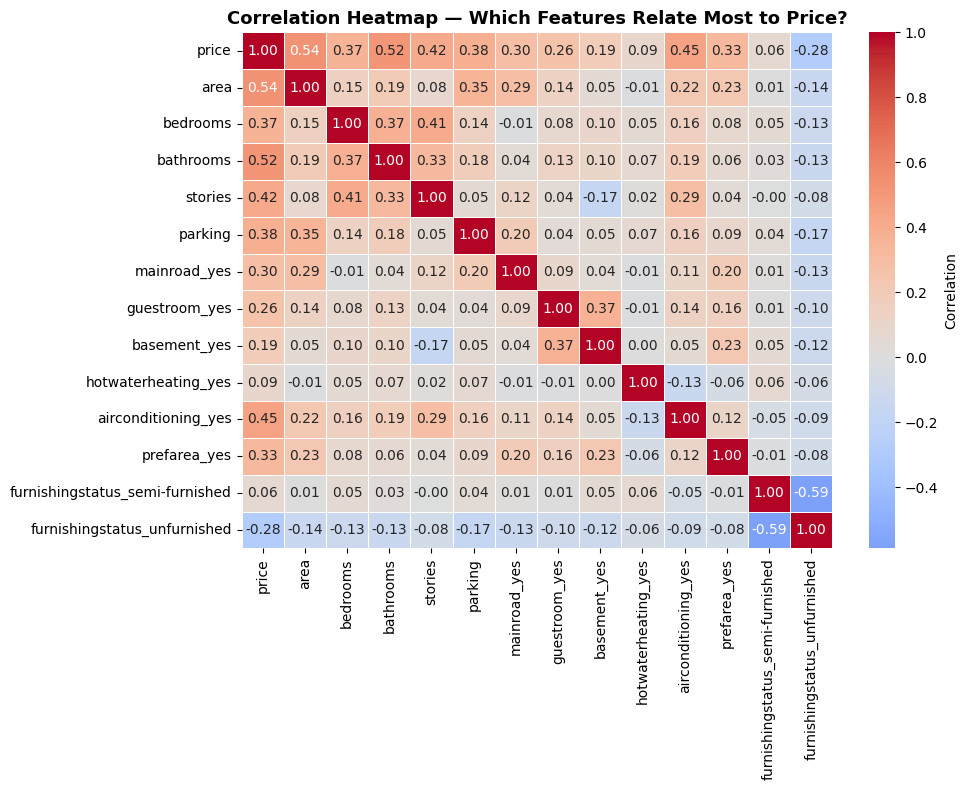

In [16]:
# Chart 2 : Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — Which Features Relate Most to Price?",
          fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

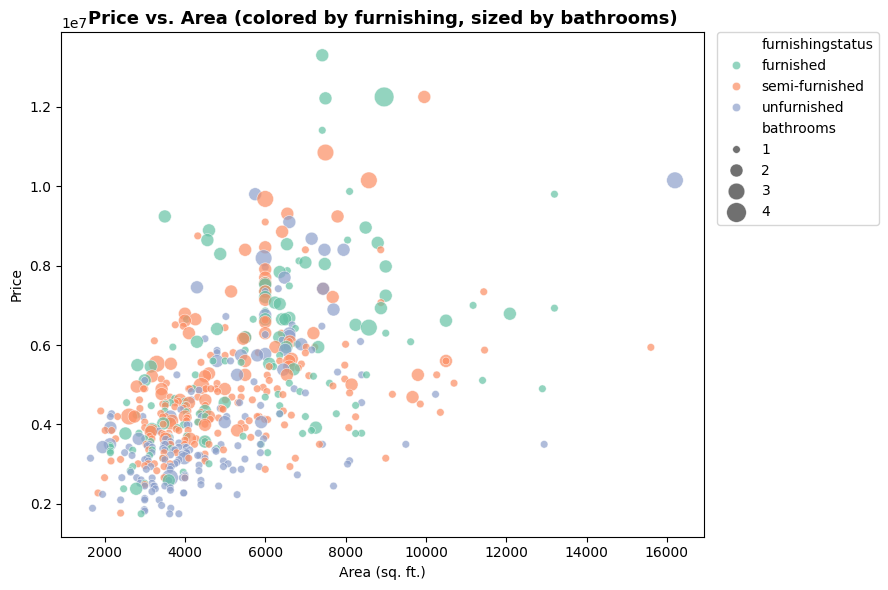

In [17]:
# Chart 3 : Creative chart: Price vs Area
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="area", y="price",
    hue="furnishingstatus", size="bathrooms",
    sizes=(30, 200), alpha=0.7, palette="Set2"
)
plt.title("Price vs. Area (colored by furnishing, sized by bathrooms)",
          fontsize=13, weight="bold")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

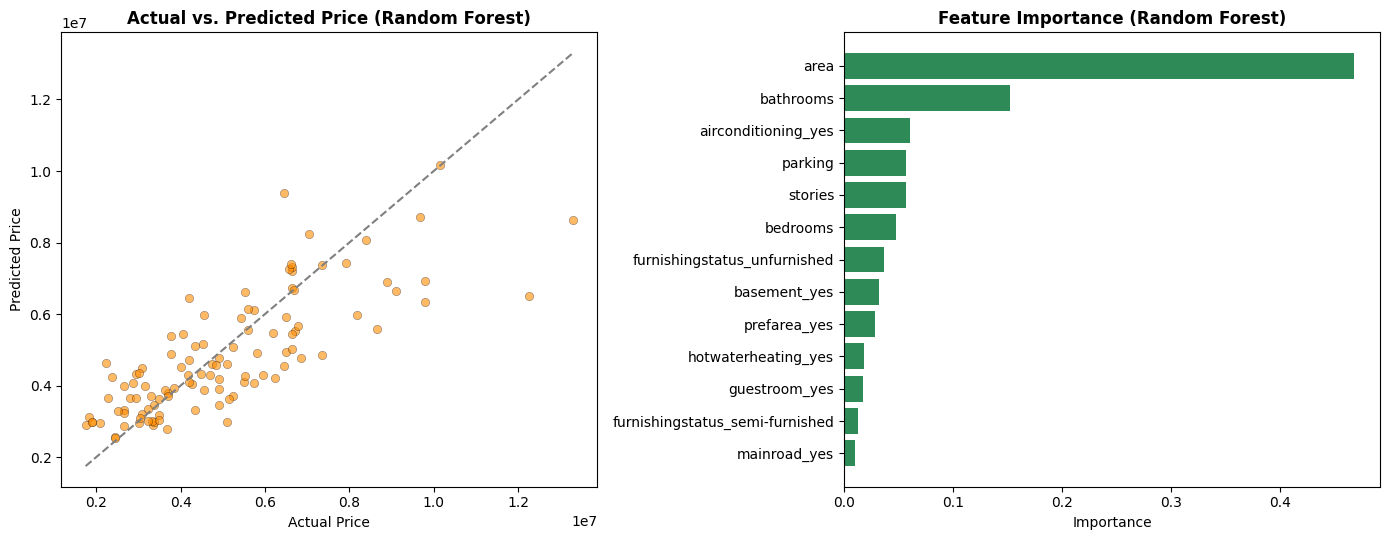

In [18]:
# Chart 4 : Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test, rf_preds, alpha=0.6, color="darkorange", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
axes[0].plot(lims, lims, "--", color="gray", linewidth=1.5)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Actual vs. Predicted Price (Random Forest)", weight="bold")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
axes[1].barh(importances.index, importances.values, color="seagreen")
axes[1].set_title("Feature Importance (Random Forest)", weight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [19]:
# Insights and Conclusion:

# Looking at the correlation heatmap and feature importance chart, it's pretty clear
# that area has the biggest impact on house prices. After that, factors like the
# number of bathrooms, air conditioning, and number of stories also make a noticeable
# difference. In simple terms, bigger houses with more bathrooms and better amenities
# usually have higher prices.

# My Linear Regression model achieved an R² score of around 0.65, which means it was
# able to explain about 65% of the variation in house prices. The average prediction
# error was around ₹9.7 lakh, so while the model gives a reasonable estimate, it's not
# accurate enough to predict the exact price every time.

# One thing I found interesting was that Linear Regression performed slightly better
# than Random Forest. Normally, Random Forest is expected to give better results, but
# I think because the dataset has only around 545 records, the simpler Linear Regression
# model was enough to capture the overall pattern without overcomplicating things.

# Overall, I'd suggest that a real estate business should give the most importance to
# area and bathroom count while pricing a house. Features like air conditioning,
# parking, and location should also be considered, but the model shouldn't be the
# only basis for deciding the final price since there's still a fair amount of
# variation it can't explain.